# 03 · Positional encoding — adding order

Attention (next notebook) looks at all tokens **at once** — it has no built-in sense of order.
Without help, `"cat chases mouse"` and `"mouse chases cat"` would look identical.

Fix: add a **position signal** to each token's embedding. The original Transformer uses fixed
**sine/cosine waves** of different frequencies, so every position gets a unique, smooth
fingerprint the model can decode.

In [1]:
import numpy as np

def positional_encoding(seq_len, d_model):
    pos = np.arange(seq_len)[:, None]                       # (seq_len, 1) row = position
    i   = np.arange(d_model)[None, :]                       # (1, d_model) col = dimension
    angle = pos / np.power(10000, (2 * (i // 2)) / d_model) # low dims wiggle fast, high dims slow
    pe = np.zeros((seq_len, d_model))
    pe[:, 0::2] = np.sin(angle[:, 0::2])                    # even dimensions -> sine
    pe[:, 1::2] = np.cos(angle[:, 1::2])                    # odd  dimensions -> cosine
    return pe

pe = positional_encoding(seq_len=6, d_model=8)
print("PE shape:", pe.shape, "= (positions, d_model)")
print("position 0 vector:", pe[0].round(2))
print("position 1 vector:", pe[1].round(2), " <- different fingerprint")

PE shape: (6, 8) = (positions, d_model)
position 0 vector: [0. 1. 0. 1. 0. 1. 0. 1.]
position 1 vector: [0.84 0.54 0.1  1.   0.01 1.   0.   1.  ]  <- different fingerprint


### Visual: the classic positional-encoding heatmap

Each **row** is a position, each **column** a dimension. Left columns oscillate quickly, right
columns slowly — together they encode position like the digits of a multi-base clock.

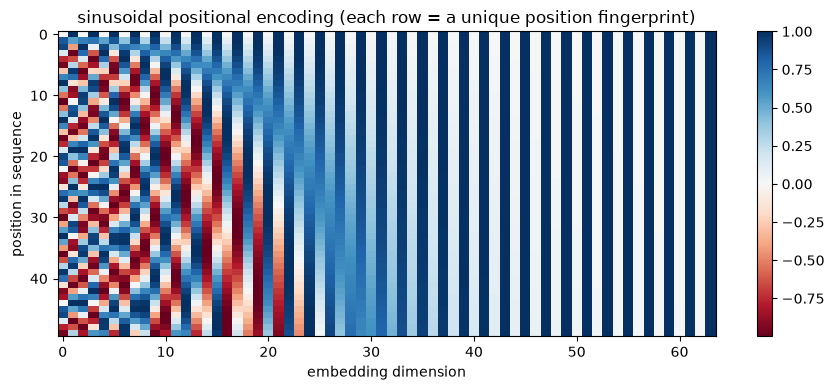

In [2]:
import matplotlib.pyplot as plt

pe = positional_encoding(seq_len=50, d_model=64)
fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(pe, cmap="RdBu", aspect="auto")
ax.set_xlabel("embedding dimension"); ax.set_ylabel("position in sequence")
ax.set_title("sinusoidal positional encoding (each row = a unique position fingerprint)")
fig.colorbar(im, ax=ax); plt.tight_layout(); plt.show()

We simply **add** this to the token embeddings: `X = embeddings + PE`. Now identical words
at different positions get slightly different vectors.

**Takeaway.** Position is injected, not learned by attention. (Modern models often use
**RoPE** instead — covered in notebook 11.) Next: **04 · self-attention**, the heart.